# Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ingestion

In [2]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

# Dataset Overview

In [3]:
print(train.shape)
print("-----------------------------")
print(train.info())
print("-----------------------------")
print(train.describe(include='all'))
print("-----------------------------")
# Missing values
missing = train.isnull().sum().sort_values(ascending=False)
print(missing)
print("-----------------------------")
# % missing
missing_pct = (train.isnull().sum() / len(train)) * 100
print(missing_pct.sort_values(ascending=False))

(891, 12)
-----------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
-----------------------------
        PassengerId    Survived      Pclass                 Name   Sex  \
count    891.000000  891.000000  891.000000                  891   891   
unique          NaN  

Q: How come age can be in decimals?

A: Some passengers were infants (e.g., 0.42 years ≈ 5 months),Some ages were estimated, not exact

In [4]:
train[(train["Age"].notnull()) & (train["Age"] % 1 != 0)][["PassengerId", "Age"]].head(10)

,PassengerId,Age
57,58,28.50
78,79,0.83
111,112,14.50
116,117,70.50
122,123,32.50
123,124,32.50
148,149,36.50
152,153,55.50
153,154,40.50
203,204,45.50


Q: Can we fill missing age with mean from looking into the Parch/sbips so it is even more accurate

A: Some passengers were infants (e.g., 0.42 years ≈ 5 months),Some ages were estimated, not exact

#  

# Target Variable Analysis

Questions:
Is the dataset imbalanced?

Do you need:
class weights?
stratified split?

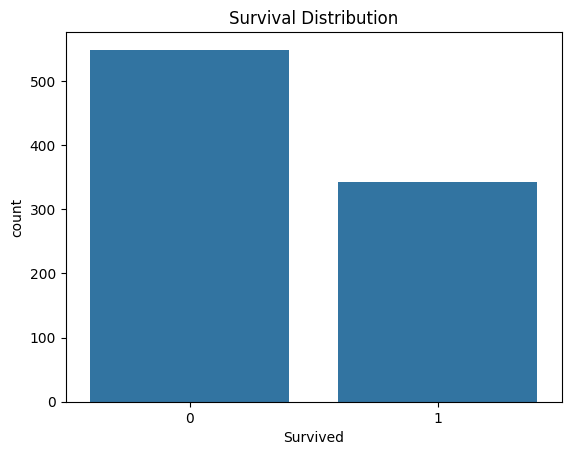

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [5]:
sns.countplot(x="Survived", data=train)
plt.title("Survival Distribution")
plt.show()
print(train["Survived"].value_counts(normalize=True))

# Univariate Analysis 

Numerical Features

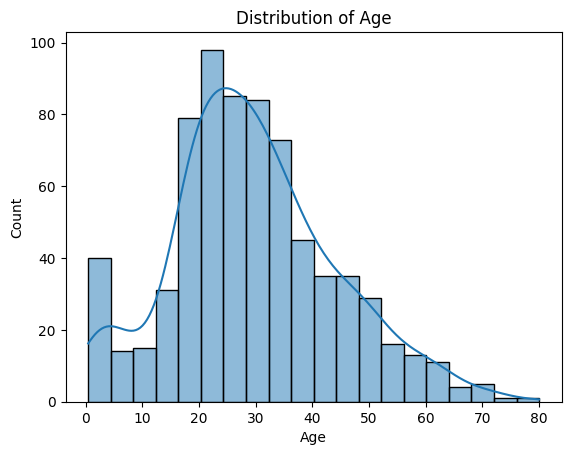

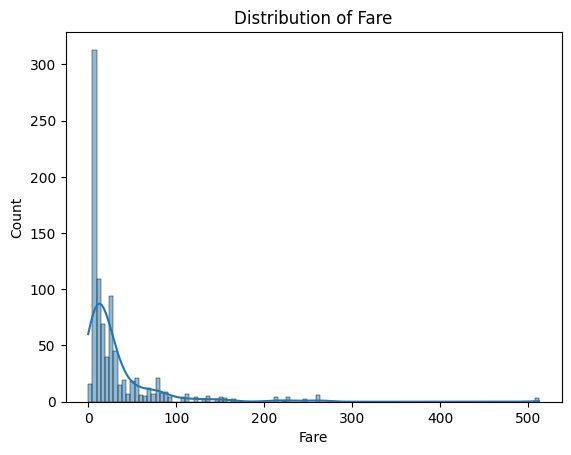

In [6]:
num_cols = ["Age", "Fare"]

for col in num_cols:
    plt.figure()
    sns.histplot(train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

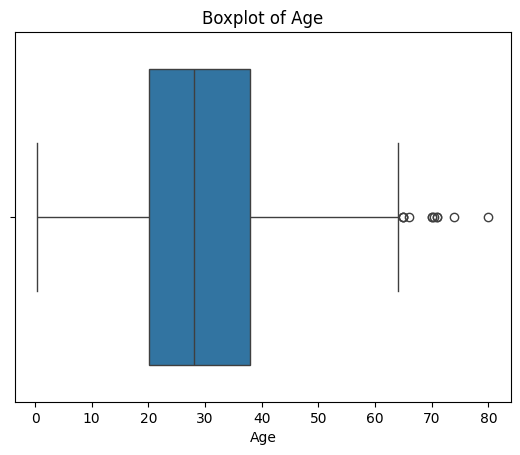

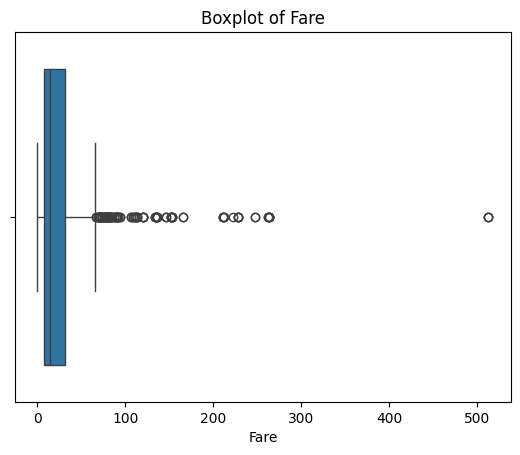

In [7]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=train[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Categorical Features

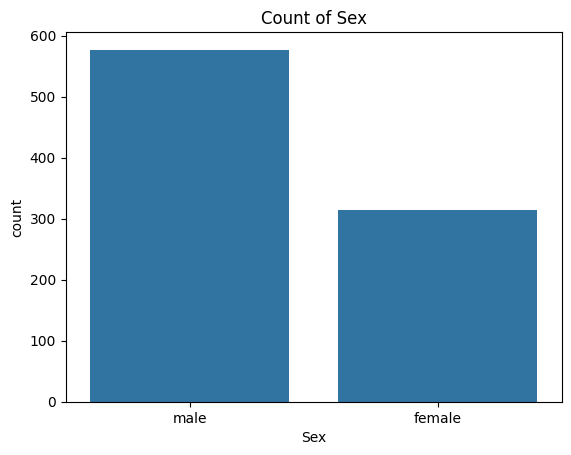

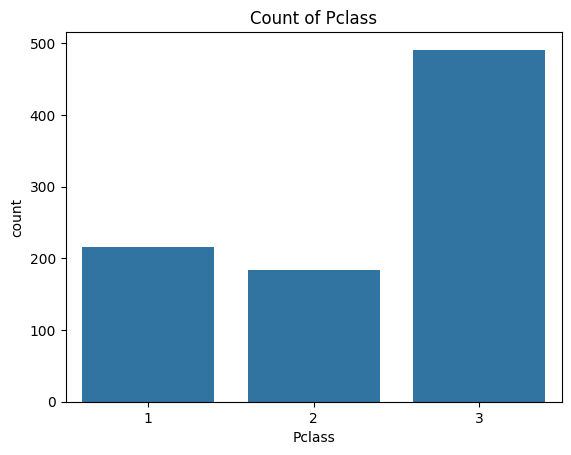

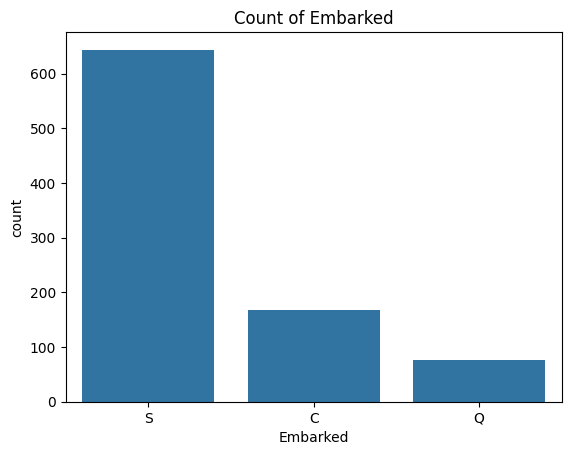

In [8]:
cat_cols = ["Sex", "Pclass", "Embarked"]

for col in cat_cols:
    sns.countplot(x=col, data=train)
    plt.title(f"Count of {col}")
    plt.show()

# Bivariate Analysis

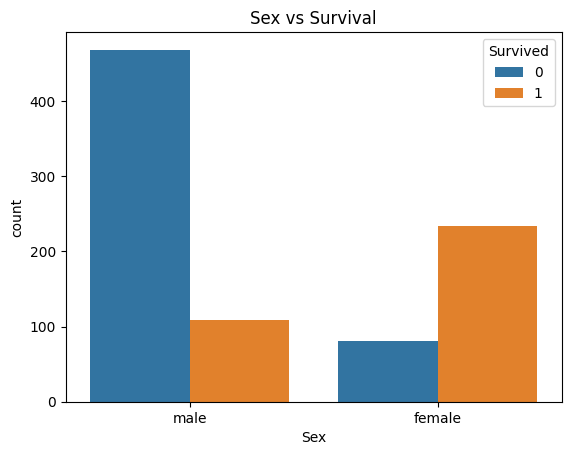

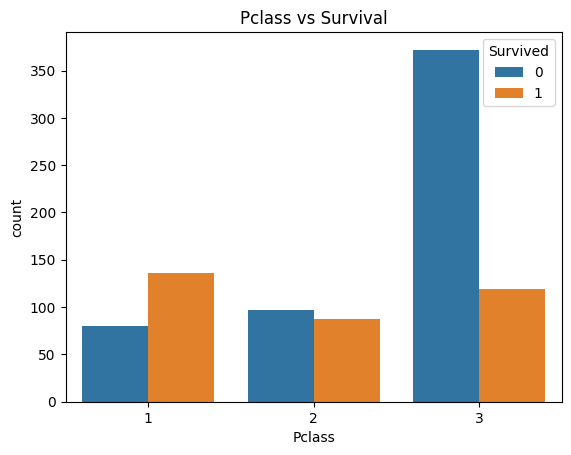

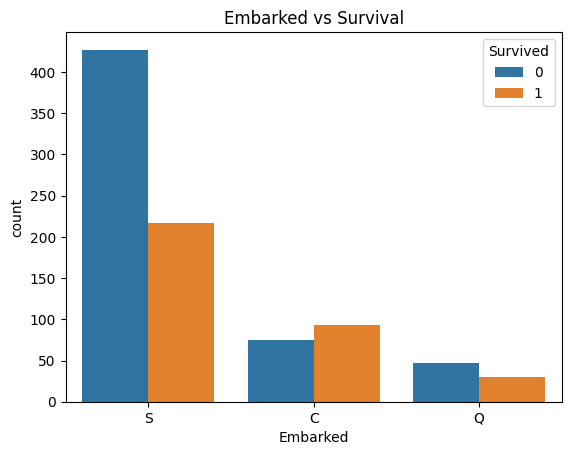

In [9]:
for col in cat_cols:
    sns.countplot(x=col, hue="Survived", data=train)
    plt.title(f"{col} vs Survival")
    plt.show()

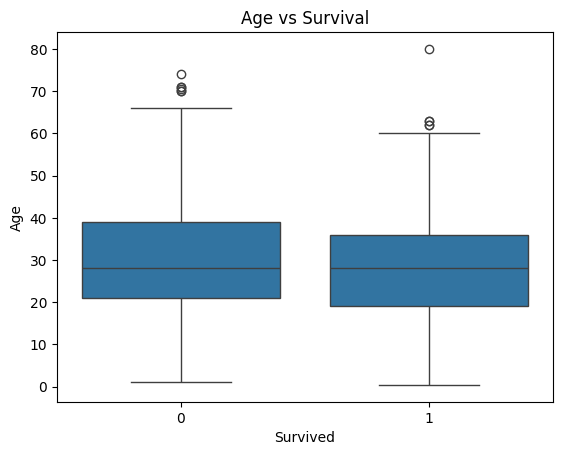

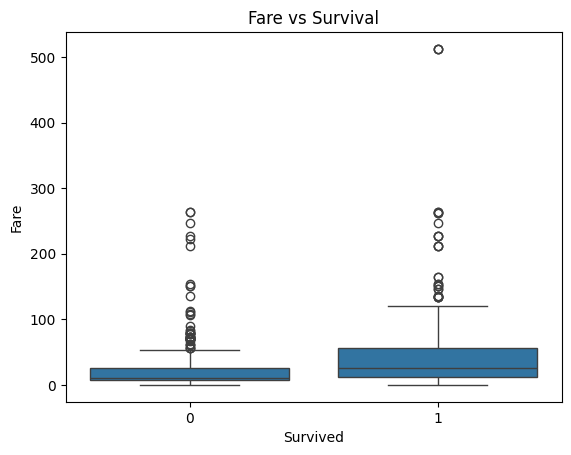

In [10]:
for col in num_cols:
    sns.boxplot(x="Survived", y=col, data=train)
    plt.title(f"{col} vs Survival")
    plt.show()

# Correlation Analysis

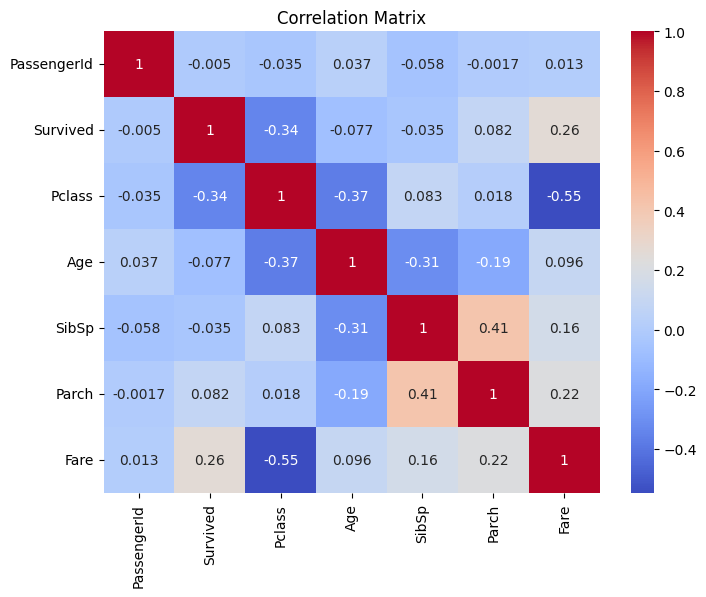

In [11]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Missing Value Pattern Analysis

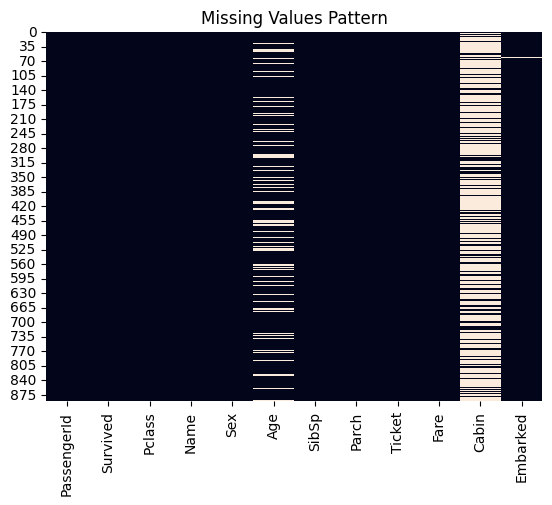

In [12]:
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Values Pattern")
plt.show()

# Feature Engineering Clues

In [13]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

train["IsAlone"] = (train["FamilySize"] == 1).astype(int)
test["IsAlone"] = (test["FamilySize"] == 1).astype(int)

train["Title"] = train["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)
test["Title"] = test["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_16/4024186016.py:7: SyntaxWarning: invalid escape sequence '\.'
  train["Title"] = train["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)
/tmp/ipykernel_16/4024186016.py:8: SyntaxWarning: invalid escape sequence '\.'
  test["Title"] = test["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)


# Documentation-Ready Summary

# Drop Useless / Problematic Columns

In [14]:
train = train.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)
test = test.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Handle Remaining Missing Values

In [15]:
test.isnull().sum()

Pclass         0
Sex            0
Age           86
SibSp          0
Parch          0
Fare           1
Embarked       0
FamilySize     0
IsAlone        0
Title          0
dtype: int64

In [16]:
train["Embarked"].fillna(train["Embarked"].mode()[0], inplace=True)
test["Embarked"].fillna(train["Embarked"].mode()[0], inplace=True)

/tmp/ipykernel_16/1724505569.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Embarked"].fillna(train["Embarked"].mode()[0], inplace=True)
/tmp/ipykernel_16/1724505569.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [17]:
test["Fare"].fillna(train["Fare"].median(), inplace=True)

/tmp/ipykernel_16/90849502.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test["Fare"].fillna(train["Fare"].median(), inplace=True)


In [18]:
train["Age"] = train.groupby(["Title", "Pclass"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

# Encode Categorical Variables

In [19]:
train = pd.get_dummies(train, columns=["Sex", "Embarked", "Title"], drop_first=True)
test = pd.get_dummies(test, columns=["Sex", "Embarked", "Title"], drop_first=True)

# Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["Age", "Fare", "FamilySize"]

train[num_cols] = scaler.fit_transform(train[num_cols])

test[num_cols] = scaler.transform(test[num_cols])

# Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

X = train.drop("Survived", axis=1)
y = train["Survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Model

LogisticRegression

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_val)

print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.88       110
           1       0.82      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

[[98 12]
 [16 53]]


RandomForestClassifier

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [25]:
y_pred = rf.predict(X_val)

print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

[[94 16]
 [19 50]]


In [26]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance)

           feature  importance
4             Fare    0.247784
1              Age    0.208523
21        Title_Mr    0.131070
7         Sex_male    0.109751
0           Pclass    0.078822
5       FamilySize    0.045414
18      Title_Miss    0.034110
22       Title_Mrs    0.031804
2            SibSp    0.029225
3            Parch    0.022601
9       Embarked_S    0.021459
8       Embarked_Q    0.010640
6          IsAlone    0.010135
17    Title_Master    0.006386
24       Title_Rev    0.004659
13        Title_Dr    0.001873
10       Title_Col    0.001570
12       Title_Don    0.001339
16     Title_Major    0.001041
14  Title_Jonkheer    0.000704
25       Title_Sir    0.000369
19      Title_Mlle    0.000338
23        Title_Ms    0.000229
15      Title_Lady    0.000154
11  Title_Countess    0.000000
20       Title_Mme    0.000000


XGBClassifier

In [27]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [28]:
y_pred = xgb.predict(X_val)

print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.75      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.81      0.80      0.80       179

[[92 18]
 [17 52]]


In [29]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance)

           feature  importance
24       Title_Rev    0.356218
21        Title_Mr    0.310628
13        Title_Dr    0.096507
7         Sex_male    0.074901
0           Pclass    0.047764
5       FamilySize    0.030338
18      Title_Miss    0.014046
9       Embarked_S    0.013231
4             Fare    0.012820
2            SibSp    0.011393
1              Age    0.010439
8       Embarked_Q    0.008533
22       Title_Mrs    0.008441
3            Parch    0.004741
6          IsAlone    0.000000
10       Title_Col    0.000000
11  Title_Countess    0.000000
12       Title_Don    0.000000
17    Title_Master    0.000000
16     Title_Major    0.000000
15      Title_Lady    0.000000
14  Title_Jonkheer    0.000000
20       Title_Mme    0.000000
19      Title_Mlle    0.000000
23        Title_Ms    0.000000
25       Title_Sir    0.000000
